Processing: Normal Lung
Number of Segments generated: 282
Computation Time:   0.1827 seconds
Mean Squared Error: 407.2409
PSNR:               22.03 dB
------------------------------


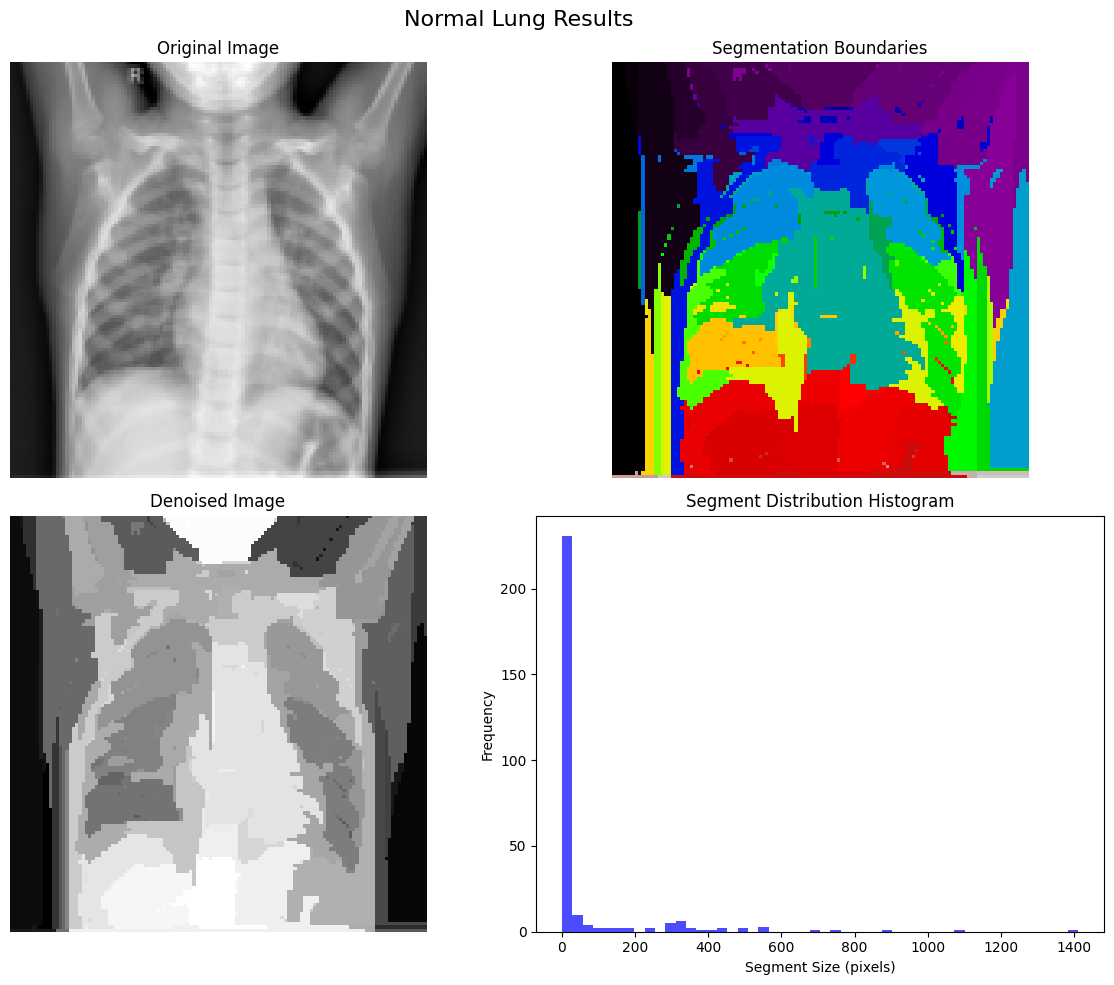

Processing: Viral Pneumonia
Number of Segments generated: 218
Computation Time:   0.1828 seconds
Mean Squared Error: 254.8476
PSNR:               24.07 dB
------------------------------


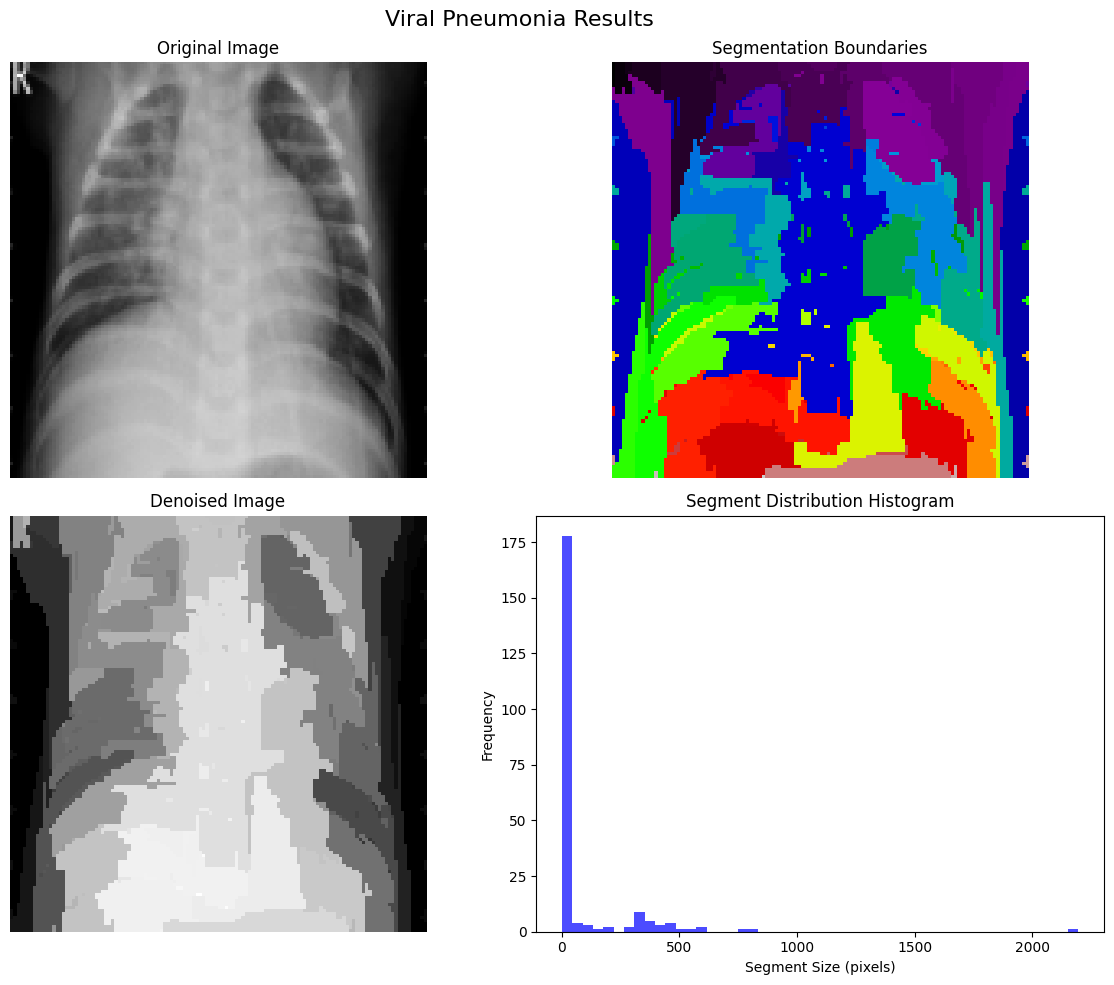

Processing: Bacterial Pneumonia
Number of Segments generated: 216
Computation Time:   0.1863 seconds
Mean Squared Error: 203.0189
PSNR:               25.06 dB
------------------------------


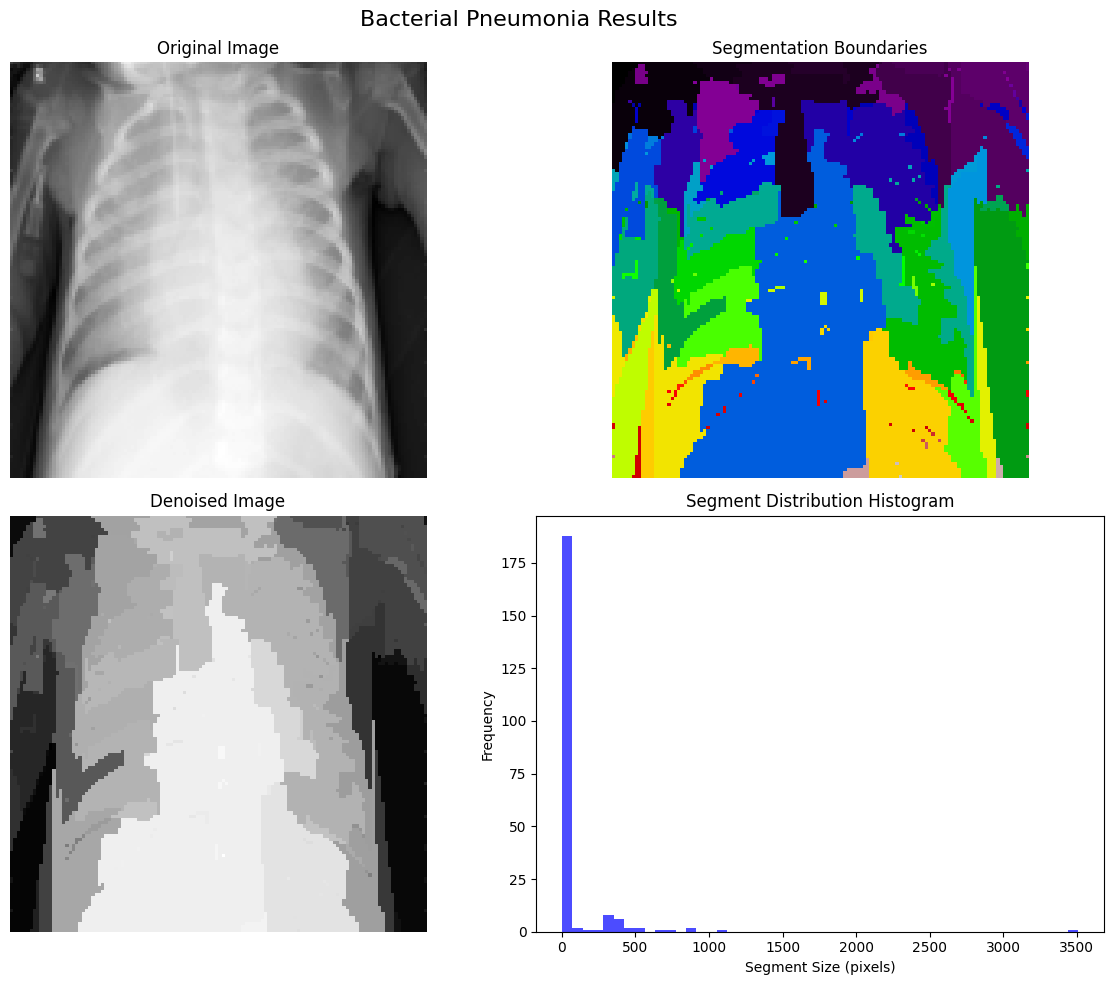

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color
from skimage.transform import resize
from collections import defaultdict
import time
import math
from scipy import ndimage

class UnionFind:
    """Union-Find data structure for component management[cite: 78]."""
    def __init__(self, num_elements):
        self.parent = np.arange(num_elements)
        self.size = np.ones(num_elements, dtype=int)
        # Tracks Int(C), the maximum weight in the component's MST 
        self.max_weight = np.zeros(num_elements, dtype=float)

    def find(self, i):
        # Path compression for efficiency
        if self.parent[i] == i:
            return i
        self.parent[i] = self.find(self.parent[i])
        return self.parent[i]

    def union(self, i, j, weight):
        root_i = self.find(i)
        root_j = self.find(j)

        if root_i != root_j:
            # Merge smaller component into larger one
            if self.size[root_i] < self.size[root_j]:
                root_i, root_j = root_j, root_i

            self.parent[root_j] = root_i
            self.size[root_i] += self.size[root_j]
            # The edge causing the merge is the new maximum weight in the MST
            self.max_weight[root_i] = weight

def load_and_preprocess_image(filepath, target_size=(128, 128)):
    """Loads, converts to grayscale, and resizes the medical image"""
    img = io.imread(filepath)
    if len(img.shape) >= 3:
        img = color.rgb2gray(img)

    # Resize to prevent excessive computation time
    img_resized = resize(img, target_size, anti_aliasing=True)
    # Ensure intensity values are in [0, 255] [cite: 23]
    return (img_resized * 255).astype(np.uint8)

def build_graph(image):
    """Constructs the graph representation of the input image ."""
    m, n = image.shape
    edges = []

    # Connect 4-neighbor pixels [cite: 25]
    for i in range(m):
        for j in range(n):
            current_node = i * n + j

            # Edge to the right neighbor
            if j < n - 1:
                right_node = i * n + (j + 1)
                # w(e) = |I(i,j) - I(k,l)| [cite: 39-40]
                weight = abs(float(image[i, j]) - float(image[i, j + 1]))
                edges.append((weight, current_node, right_node))

            # Edge to the bottom neighbor
            if i < m - 1:
                bottom_node = (i + 1) * n + j
                weight = abs(float(image[i, j]) - float(image[i + 1, j]))
                edges.append((weight, current_node, bottom_node))

    return edges, m, n

def segment_image(image, k=150):
    """Applies modified Kruskal's algorithm for segmentation """
    start_time = time.time()

    edges, m, n = build_graph(image)
    num_pixels = m * n
    uf = UnionFind(num_pixels)

    # Sort edges by weight in non-decreasing order 
    edges.sort(key=lambda x: x[0])

    for weight, u, v in edges:
        root_u = uf.find(u)
        root_v = uf.find(v)

        if root_u != root_v:
            # Adaptive thresholding tau(C) = k / |C| 
            tau_u = k / uf.size[root_u]
            tau_v = k / uf.size[root_v]

            # Merging criterion threshold 
            if weight <= min(uf.max_weight[root_u] + tau_u, uf.max_weight[root_v] + tau_v):
                uf.union(root_u, root_v, weight)

    computation_time = time.time() - start_time
    return uf, m, n, computation_time

def denoise_image(image, uf, m, n):
    """Implements denoising through segment means [cite: 32, 56-58, 81-85]."""
    denoised_image = np.zeros_like(image, dtype=float)
    segment_sums = defaultdict(float)

    # Compute sum of intensities per segment 
    for i in range(m):
        for j in range(n):
            node = i * n + j
            root = uf.find(node)
            segment_sums[root] += image[i, j]

    # Replace pixel values with segment means 
    for i in range(m):
        for j in range(n):
            node = i * n + j
            root = uf.find(node)
            denoised_image[i, j] = segment_sums[root] / uf.size[root]

    return denoised_image

def calculate_metrics(original, denoised, uf, m, n, comp_time):
    """Evaluates performance using appropriate metrics """
    unique_segments = len(set(uf.find(i) for i in range(m * n))) 
    mse = np.mean((original.astype(float) - denoised.astype(float)) ** 2) 

    if mse == 0:
        psnr = float('inf')
    else:
        max_pixel = 255.0
        psnr = 20 * math.log10(max_pixel / math.sqrt(mse)) 

    print(f"Number of Segments generated: {unique_segments}") 
    print(f"Computation Time:   {comp_time:.4f} seconds") 
    print(f"Mean Squared Error: {mse:.4f}") 
    print(f"PSNR:               {psnr:.2f} dB") 
    print("-" * 30)

def visualize_results(original, denoised, uf, m, n, title_prefix=""):
    """Visualizes the segmentation and denoising results."""
    segment_map = np.zeros((m, n))
    segment_sizes = []

    root_to_label = {}
    current_label = 1

    for i in range(m):
        for j in range(n):
            node = i * n + j
            root = uf.find(node)
            if root not in root_to_label:
                root_to_label[root] = current_label
                current_label += 1
                segment_sizes.append(uf.size[root])
            segment_map[i, j] = root_to_label[root]

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(f"{title_prefix} Results", fontsize=16)

    axes[0, 0].imshow(original, cmap='gray')
    axes[0, 0].set_title('Original Image') 
    axes[0, 0].axis('off')

    axes[0, 1].imshow(segment_map, cmap='nipy_spectral')
    axes[0, 1].set_title('Segmentation Boundaries') 
    axes[0, 1].axis('off')

    axes[1, 0].imshow(denoised, cmap='gray')
    axes[1, 0].set_title('Denoised Image') 
    axes[1, 0].axis('off')

    axes[1, 1].hist(segment_sizes, bins=50, color='blue', alpha=0.7)
    axes[1, 1].set_title('Segment Distribution Histogram') 
    axes[1, 1].set_xlabel('Segment Size (pixels)')
    axes[1, 1].set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()

# ==========================================
# MAIN EXECUTION BLOCK
# ==========================================
if __name__ == "__main__":
   
    image_paths = {
        "Normal Lung": "images/normal_xray.jpeg",
        "Viral Pneumonia": "images/viral_pneumonia.jpeg",
        "Bacterial Pneumonia": "images/bacterial_pneumonia.jpeg"
    }


    k_parameter = 300

    for label, path in image_paths.items():
        print(f"Processing: {label}")
        try:
            # 1. Load and preprocess [cite: 70]
            img = load_and_preprocess_image(path, target_size=(128, 128))

            # 2. MST Segmentation [cite: 31, 76]
            uf_structure, h, w, time_taken = segment_image(img, k=k_parameter)

            # 3. Denoising [cite: 32, 81]
            denoised_img = denoise_image(img, uf_structure, h, w)

            # 4. Evaluation and Visualization [cite: 33, 34, 86]
            calculate_metrics(img, denoised_img, uf_structure, h, w, time_taken)
            visualize_results(img, denoised_img, uf_structure, h, w, title_prefix=label)

        except FileNotFoundError:
            print(f"Could not find the file at {path}. Please update the file path.")
            print("-" * 30)